# Advanced Analytics + Risk Metrics

Bluestock Fintech 24J — Mutual Fund Analytics Capstone

This notebook implements historical VaR/CVaR, 90-day rolling Sharpe, investor cohort analysis, SIP continuity, risk-based recommendations, sector HHI concentration, and five advanced insights.

In [2]:
# ============================================================
# Advanced Analytics + Risk Metrics
# Mutual Fund Analytics
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Define project paths
# ------------------------------------------------------------

# Notebook is inside: MutualFundAnalytics/notebooks/
# Therefore, parent directory is the project root.
PROJECT_ROOT = Path.cwd().parent

DATA = PROJECT_ROOT / "data"
RAW = DATA / "raw"
PROCESSED = DATA / "processed"

# All generated outputs go to the project's main outputs folder
OUT = PROJECT_ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Display paths for verification
# ------------------------------------------------------------

print("Project Root :", PROJECT_ROOT)
print("Raw Data     :", RAW)
print("Processed    :", PROCESSED)
print("Output Folder:", OUT)

# ------------------------------------------------------------
# 3. Load processed datasets
# ------------------------------------------------------------

nav = pd.read_csv(
    PROCESSED / "02_nav_history_clean.csv",
    parse_dates=["date"]
)

perf = pd.read_csv(
    PROCESSED / "07_scheme_performance_clean.csv"
)

tx = pd.read_csv(
    PROCESSED / "08_investor_transactions_clean.csv",
    parse_dates=["transaction_date"]
)

# ------------------------------------------------------------
# 4. Load fund master data
# ------------------------------------------------------------

fund = pd.read_csv(
    RAW / "01_fund_master.csv",
    parse_dates=["launch_date"]
)

# ------------------------------------------------------------
# 5. Display dataset information
# ------------------------------------------------------------

print("\nDataset Shapes")
print("-" * 50)
print("NAV History       :", nav.shape)
print("Scheme Performance:", perf.shape)
print("Transactions      :", tx.shape)
print("Fund Master       :", fund.shape)

print("\nNAV Columns:")
print(nav.columns.tolist())

print("\nPerformance Columns:")
print(perf.columns.tolist())

print("\nTransaction Columns:")
print(tx.columns.tolist())

print("\nFund Master Columns:")
print(fund.columns.tolist())

Project Root : /Users/gowrishhg/Desktop/MutualFundAnalytics
Raw Data     : /Users/gowrishhg/Desktop/MutualFundAnalytics/data/raw
Processed    : /Users/gowrishhg/Desktop/MutualFundAnalytics/data/processed
Output Folder: /Users/gowrishhg/Desktop/MutualFundAnalytics/outputs

Dataset Shapes
--------------------------------------------------
NAV History       : (46000, 3)
Scheme Performance: (40, 19)
Transactions      : (32778, 13)
Fund Master       : (40, 15)

NAV Columns:
['amfi_code', 'date', 'nav']

Performance Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Transaction Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh'

## 1. Historical VaR and CVaR (95%)
VaR is the 5th percentile of daily returns. CVaR is the mean return conditional on returns at or below the VaR threshold. More negative values indicate worse downside tail risk.

In [3]:
nav = nav.sort_values(['amfi_code','date']).drop_duplicates(['amfi_code','date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
rows=[]
for code,g in nav.groupby('amfi_code'):
    r=g['daily_return'].dropna()
    var=r.quantile(0.05)
    tail=r[r<=var]
    rows.append({'amfi_code':code,'VaR_95_daily_pct':var*100,'CVaR_95_daily_pct':tail.mean()*100,'observations':len(r),'tail_observations':len(tail)})
var_cvar=pd.DataFrame(rows).merge(perf[['amfi_code','scheme_name','category','risk_grade','sharpe_ratio','aum_crore']],on='amfi_code',how='left').sort_values('VaR_95_daily_pct')
var_cvar.to_csv(OUT/'var_cvar_report.csv',index=False)
var_cvar.head(10)

,amfi_code,VaR_95_daily_pct,CVaR_95_daily_pct,observations,tail_observations,scheme_name,category,risk_grade,sharpe_ratio,aum_crore
22,119599,-2.685944,-3.238412,1149,58,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,Very High,0.93,36061
17,119095,-2.618842,-3.166729,1149,58,Axis Small Cap Fund - Regular - Growth,Small Cap,Very High,0.84,21545
4,101207,-2.602125,-3.245906,1149,58,ABSL Small Cap Fund - Regular - Growth,Small Cap,Very High,0.90,41613
11,118634,-2.543811,-3.230407,1149,58,Nippon India Small Cap Fund - Regular - Growth,Small Cap,Very High,0.81,43630
21,119598,-2.450705,-3.059526,1149,58,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,Very High,0.94,19259
39,149324,-2.348307,-3.103625,1149,58,DSP Small Cap Fund - Regular - Growth,Small Cap,Very High,0.80,35124
7,102886,-1.922028,-2.325086,1149,58,UTI Mid Cap Fund - Regular - Growth,Mid Cap,High,0.82,41728
2,100033,-1.903354,-2.345576,1149,58,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,High,0.87,23185
25,120505,-1.889179,-2.434207,1149,58,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,High,0.95,979
16,119094,-1.848028,-2.426006,1149,58,Axis Midcap Fund - Regular - Growth,Mid Cap,High,0.80,28996


## 2. 90-Day Rolling Annualized Sharpe
Formula: `sqrt(252) × rolling_mean_daily_return / rolling_std_daily_return`. The five largest funds by AUM are used as the key-fund comparison set.

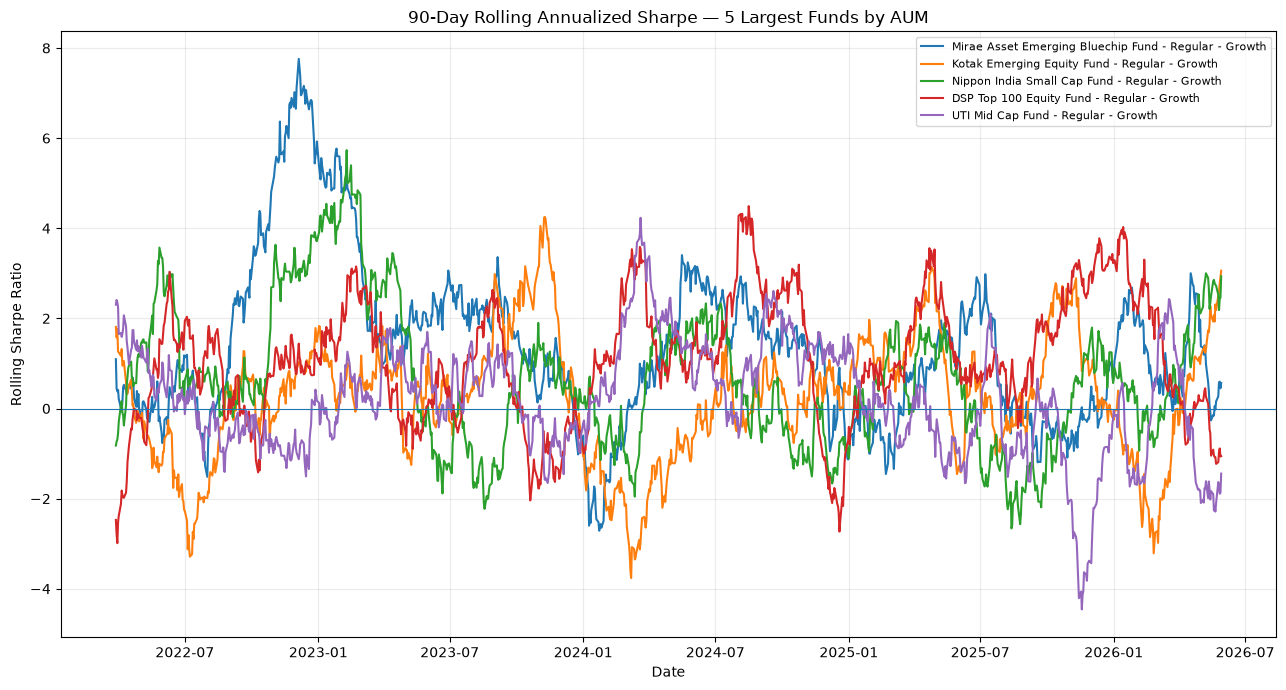

In [4]:
nav['rolling_mean_90']=nav.groupby('amfi_code')['daily_return'].transform(lambda s:s.rolling(90,min_periods=60).mean())
nav['rolling_std_90']=nav.groupby('amfi_code')['daily_return'].transform(lambda s:s.rolling(90,min_periods=60).std())
nav['rolling_sharpe_90d']=np.sqrt(252)*nav['rolling_mean_90']/nav['rolling_std_90']
key_funds=perf.sort_values('aum_crore',ascending=False).head(5)[['amfi_code','scheme_name','aum_crore']]
plt.figure(figsize=(13,7))
for _,row in key_funds.iterrows():
    g=nav[nav.amfi_code.eq(row.amfi_code)]
    plt.plot(g.date,g.rolling_sharpe_90d,label=row.scheme_name)
plt.axhline(0,linewidth=.8)
plt.title('90-Day Rolling Annualized Sharpe — 5 Largest Funds by AUM')
plt.xlabel('Date'); plt.ylabel('Rolling Sharpe Ratio'); plt.legend(fontsize=8); plt.grid(alpha=.25); plt.tight_layout()
plt.savefig(OUT/'rolling_sharpe_chart.png',dpi=180); plt.show()

## 3. Investor Cohort Analysis
Cohorts are defined by each investor's first transaction year. Gross invested amount includes SIP and Lumpsum transactions; redemptions are excluded from gross investment. Top fund preference is based on investment transaction count.

In [8]:
# ============================================================
# 3. Investor Cohort Analysis
# ============================================================

# Make a copy of the transaction data
investor_tx = tx.copy()

# ------------------------------------------------------------
# 1. Prepare transaction dates
# ------------------------------------------------------------

investor_tx["transaction_date"] = pd.to_datetime(
    investor_tx["transaction_date"],
    errors="coerce"
)

# Remove invalid investor/date records
investor_tx = investor_tx.dropna(
    subset=["investor_id", "transaction_date"]
).copy()

# ------------------------------------------------------------
# 2. Identify the scheme/fund column automatically
# ------------------------------------------------------------

possible_scheme_columns = [
    "scheme_name",
    "scheme",
    "fund_name",
    "fund",
    "scheme_code",
    "amfi_code"
]

scheme_col = None

for col in possible_scheme_columns:
    if col in investor_tx.columns:
        scheme_col = col
        break

if scheme_col is None:
    raise KeyError(
        "Could not find a scheme/fund column. "
        f"Available columns are: {investor_tx.columns.tolist()}"
    )

print("Using scheme column:", scheme_col)

# ------------------------------------------------------------
# 3. Find each investor's first transaction
# ------------------------------------------------------------

first_transaction = (
    investor_tx
    .groupby("investor_id")["transaction_date"]
    .min()
    .rename("first_transaction_date")
)

investor_tx = investor_tx.merge(
    first_transaction,
    on="investor_id",
    how="left"
)

# First transaction year
investor_tx["first_transaction_year"] = (
    investor_tx["first_transaction_date"].dt.year
)

# ------------------------------------------------------------
# 4. Total investment per investor
# ------------------------------------------------------------

investor_total_investment = (
    investor_tx
    .groupby("investor_id")["amount_inr"]
    .sum()
    .rename("investor_total_invested_inr")
)

# ------------------------------------------------------------
# 5. Average SIP amount per investor
# ------------------------------------------------------------

sip_tx = investor_tx[
    investor_tx["transaction_type"]
    .astype(str)
    .str.lower()
    .eq("sip")
].copy()

investor_avg_sip = (
    sip_tx
    .groupby("investor_id")["amount_inr"]
    .mean()
    .rename("investor_avg_sip_amount_inr")
)

# ------------------------------------------------------------
# 6. Combine investor-level metrics
# ------------------------------------------------------------

investor_metrics = pd.concat(
    [
        investor_total_investment,
        investor_avg_sip
    ],
    axis=1
).reset_index()

# ------------------------------------------------------------
# 7. Add first transaction year
# ------------------------------------------------------------

investor_cohort = (
    investor_tx[
        ["investor_id", "first_transaction_year"]
    ]
    .drop_duplicates("investor_id")
)

investor_metrics = investor_metrics.merge(
    investor_cohort,
    on="investor_id",
    how="left"
)

# ------------------------------------------------------------
# 8. Cohort-level analysis
# ------------------------------------------------------------

cohort = (
    investor_metrics
    .groupby("first_transaction_year")
    .agg(
        investors=("investor_id", "nunique"),
        total_invested_inr=(
            "investor_total_invested_inr",
            "sum"
        ),
        avg_invested_per_investor_inr=(
            "investor_total_invested_inr",
            "mean"
        ),
        avg_sip_amount_inr=(
            "investor_avg_sip_amount_inr",
            "mean"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# 9. Fund preference by cohort
# ------------------------------------------------------------

cohort_fund = (
    investor_tx
    .groupby(
        ["first_transaction_year", scheme_col]
    )
    .agg(
        investment_transactions=(
            "amount_inr",
            "size"
        ),
        total_invested_inr=(
            "amount_inr",
            "sum"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# 10. Find top fund for each cohort
# ------------------------------------------------------------

top_fund = (
    cohort_fund
    .sort_values(
        [
            "first_transaction_year",
            "total_invested_inr"
        ],
        ascending=[True, False]
    )
    .drop_duplicates("first_transaction_year")
    [
        [
            "first_transaction_year",
            scheme_col
        ]
    ]
    .rename(
        columns={
            scheme_col: "top_fund_preference"
        }
    )
)

# ------------------------------------------------------------
# 11. Merge top fund preference
# ------------------------------------------------------------

cohort = cohort.merge(
    top_fund,
    on="first_transaction_year",
    how="left"
)

# ------------------------------------------------------------
# 12. Save result
# ------------------------------------------------------------

cohort.to_csv(
    OUT / "investor_cohort_analysis.csv",
    index=False
)

# ------------------------------------------------------------
# 13. Display result
# ------------------------------------------------------------

print("\nInvestor Cohort Analysis")
print("=" * 60)

display(cohort)

print(
    f"\nSaved to: {OUT / 'investor_cohort_analysis.csv'}"
)

Using scheme column: amfi_code

Investor Cohort Analysis


,first_transaction_year,investors,total_invested_inr,avg_invested_per_investor_inr,avg_sip_amount_inr,top_fund_preference
0,2024,4803,3491125187,726863.457631,10952.557684,102885
1,2025,197,30455243,154595.142132,13652.023551,119599



Saved to: /Users/gowrishhg/Desktop/MutualFundAnalytics/outputs/investor_cohort_analysis.csv


## 4. SIP Continuity
Only investors with 6 or more SIP transactions are included. An investor is flagged **at-risk** if any consecutive SIP gap exceeds 35 days.

In [9]:
sip=tx2[tx2.transaction_type.str.lower().eq('sip')].sort_values(['investor_id','transaction_date']).copy()
sip['gap_days']=sip.groupby('investor_id').transaction_date.diff().dt.days
eligible=sip.groupby('investor_id').size(); eligible=eligible[eligible>=6].index
sip6=sip[sip.investor_id.isin(eligible)]
continuity=sip6.groupby('investor_id').agg(sip_transactions=('transaction_date','size'),avg_gap_days=('gap_days','mean'),max_gap_days=('gap_days','max')).reset_index()
continuity['at_risk']=continuity.max_gap_days>35
continuity['continuity_rate_pct']=(continuity.sip_transactions-continuity.at_risk.astype(int))/continuity.sip_transactions*100
continuity.to_csv(OUT/'sip_continuity_analysis.csv',index=False)
print('Eligible investors:',len(continuity),'At-risk:',int(continuity.at_risk.sum()),'Not at-risk:',int((~continuity.at_risk).sum()))
continuity.head(10)

Eligible investors: 1362 At-risk: 1361 Not at-risk: 1


,investor_id,sip_transactions,avg_gap_days,max_gap_days,at_risk,continuity_rate_pct
0,INV000004,6,85.400000,265.0,True,83.333333
1,INV000008,6,70.400000,165.0,True,83.333333
2,INV000010,6,64.800000,139.0,True,83.333333
3,INV000011,7,40.166667,125.0,True,85.714286
4,INV000012,8,57.000000,132.0,True,87.500000
5,INV000013,7,55.333333,104.0,True,85.714286
6,INV000014,7,75.333333,128.0,True,85.714286
7,INV000023,8,58.571429,115.0,True,87.500000
8,INV000028,6,93.600000,238.0,True,83.333333
9,INV000029,7,60.666667,96.0,True,85.714286


## 5. Simple Fund Recommender
The recommender accepts `Low`, `Moderate`, or `High` and returns the top three funds by Sharpe ratio within the matching `risk_grade`.

In [10]:
def recommend(risk_appetite, top_n=3):
    allowed={'low':['Low'],'moderate':['Moderate'],'high':['High']}
    key=str(risk_appetite).strip().lower()
    if key not in allowed: raise ValueError('risk_appetite must be Low, Moderate, or High')
    return (perf[perf.risk_grade.isin(allowed[key])]
            .sort_values(['sharpe_ratio','return_3yr_pct'],ascending=False)
            .head(top_n)[['amfi_code','scheme_name','risk_grade','sharpe_ratio','return_3yr_pct','expense_ratio_pct']]
            .reset_index(drop=True))

for appetite in ['Low','Moderate','High']:
    print('\n',appetite)
    display(recommend(appetite))


 Low


,amfi_code,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct,expense_ratio_pct
0,120507,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68,7.68,0.74
1,120844,Kotak Liquid Fund - Regular - Growth,Low,6.18,6.18,0.60
2,101208,ABSL Liquid Fund - Regular - Growth,Low,5.14,5.14,0.79



 Moderate


,amfi_code,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06,14.84,1.55
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06,14.81,1.46
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03,14.41,0.80



 High


,amfi_code,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct,expense_ratio_pct
0,120842,Kotak Emerging Equity Fund - Regular - Growth,High,0.96,18.23,1.56
1,120505,ICICI Pru Midcap Fund - Regular - Growth,High,0.95,18.08,1.36
2,149323,DSP Midcap Fund - Regular - Growth,High,0.90,17.16,1.61


## 6. Sector HHI Concentration
For each equity fund, sector weights are converted from percentages to proportions and HHI is calculated as `Σ(weight_i²)`. HHI < 0.15 is treated as unconcentrated, 0.15–0.25 as moderately concentrated, and > 0.25 as highly concentrated.

In [14]:
# ============================================================
# 6. Sector HHI Concentration
# ============================================================

# ------------------------------------------------------------
# 1. Load portfolio holdings data
# ------------------------------------------------------------

holdings_file = RAW / "09_portfolio_holdings.csv"

if not holdings_file.exists():
    raise FileNotFoundError(
        f"Portfolio holdings file not found at:\n{holdings_file}"
    )

hold = pd.read_csv(holdings_file)

print("Portfolio holdings shape:", hold.shape)
print("Portfolio holdings columns:")
print(hold.columns.tolist())

# ------------------------------------------------------------
# 2. Merge holdings with fund master
# ------------------------------------------------------------

h = hold.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

# ------------------------------------------------------------
# 3. Keep equity funds only
# ------------------------------------------------------------

h = h[
    ~h["category"]
    .astype(str)
    .str.contains(
        "Liquid|Gilt|Short Duration",
        case=False,
        na=False
    )
].copy()

# ------------------------------------------------------------
# 4. Prepare sector weights
# ------------------------------------------------------------

h["weight_pct"] = pd.to_numeric(
    h["weight_pct"],
    errors="coerce"
)

h = h.dropna(
    subset=[
        "amfi_code",
        "sector",
        "weight_pct"
    ]
).copy()

# Convert percentage to proportion
h["weight"] = h["weight_pct"] / 100

# ------------------------------------------------------------
# 5. Calculate HHI
# ------------------------------------------------------------
# HHI = sum of squared sector weights

hhi = (
    h.groupby(
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    )
    .agg(
        hhi=(
            "weight",
            lambda x: (x ** 2).sum()
        ),
        sector_count=(
            "sector",
            "nunique"
        ),
        top_sector_weight=(
            "weight",
            "max"
        )
    )
    .reset_index()
)

# Convert top sector weight back to percentage
hhi["top_sector_weight_pct"] = (
    hhi["top_sector_weight"] * 100
)

# ------------------------------------------------------------
# 6. Classify concentration
# ------------------------------------------------------------

hhi["concentration_level"] = pd.cut(
    hhi["hhi"],
    bins=[
        -np.inf,
        0.15,
        0.25,
        np.inf
    ],
    labels=[
        "Unconcentrated",
        "Moderately concentrated",
        "Highly concentrated"
    ]
)

# ------------------------------------------------------------
# 7. Add risk/performance metrics
# ------------------------------------------------------------

metric_columns = [
    "amfi_code",
    "risk_grade",
    "sharpe_ratio",
    "aum_crore"
]

available_metrics = [
    col for col in metric_columns
    if col in perf.columns
]

if len(available_metrics) > 1:
    hhi = hhi.merge(
        perf[available_metrics].drop_duplicates(
            "amfi_code"
        ),
        on="amfi_code",
        how="left"
    )

# ------------------------------------------------------------
# 8. Sort funds by HHI
# ------------------------------------------------------------

hhi = hhi.sort_values(
    "hhi",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 9. Save HHI analysis
# ------------------------------------------------------------

hhi.to_csv(
    OUT / "sector_hhi_analysis.csv",
    index=False
)

# ------------------------------------------------------------
# 10. Display results
# ------------------------------------------------------------

print("\nTop 10 Funds by Sector HHI")
print("=" * 70)

display(
    hhi.head(10)
)

print(
    f"\nSaved to: {OUT / 'sector_hhi_analysis.csv'}"
)

Portfolio holdings shape: (322, 8)
Portfolio holdings columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Top 10 Funds by Sector HHI


,amfi_code,scheme_name,category,hhi,sector_count,top_sector_weight,top_sector_weight_pct,concentration_level,risk_grade,sharpe_ratio,aum_crore
0,119092,Axis Bluechip Fund - Regular - Growth,Equity,0.206448,7,0.3818,38.18,Moderately concentrated,Moderate,0.85,25803
1,101207,ABSL Small Cap Fund - Regular - Growth,Equity,0.200700,6,0.3507,35.07,Moderately concentrated,Very High,0.90,41613
2,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,0.174751,7,0.2825,28.25,Moderately concentrated,Very High,0.93,36061
3,102885,UTI Nifty 50 Index Fund - Regular - Growth,Equity,0.174709,8,0.2895,28.95,Moderately concentrated,Moderate,0.93,7350
4,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,0.168298,6,0.3044,30.44,Moderately concentrated,Moderate,1.00,20909
5,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity,0.167930,6,0.2861,28.61,Moderately concentrated,Moderately High,0.91,49046
6,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.157570,7,0.2346,23.46,Moderately concentrated,High,0.95,979
7,120506,ICICI Pru Value Discovery Fund - Regular - Growth,Equity,0.153794,7,0.2147,21.47,Moderately concentrated,Moderately High,0.98,2571
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,0.152414,6,0.2283,22.83,Moderately concentrated,High,0.80,18792
9,120841,Kotak Bluechip Fund - Regular - Growth,Equity,0.149680,7,0.2244,22.44,Unconcentrated,Moderate,0.87,35585



Saved to: /Users/gowrishhg/Desktop/MutualFundAnalytics/outputs/sector_hhi_analysis.csv


## 7. Five Advanced Insights
1. Identify the fund with the most adverse historical VaR.
2. Compare CVaR to understand extreme downside losses.
3. Identify the investor cohort with the highest total investment.
4. Measure SIP continuity and the share of investors flagged at-risk.
5. Identify the most sector-concentrated equity fund using HHI.

In [18]:
# ============================================================
# 7. Five Advanced Insights
# ============================================================

# ------------------------------------------------------------
# 1. Make sure required result tables are available
# ------------------------------------------------------------

# Load HHI results if the dataframe is not currently available
if "hhi" not in globals():
    hhi_file = OUT / "sector_hhi_analysis.csv"

    if hhi_file.exists():
        hhi = pd.read_csv(hhi_file)
    else:
        raise FileNotFoundError(
            "sector_hhi_analysis.csv was not found. "
            "Please run the Sector HHI section first."
        )

# Load VaR/CVaR results if necessary
if "var_cvar" not in globals():
    var_file = OUT / "var_cvar_report.csv"

    if var_file.exists():
        var_cvar = pd.read_csv(var_file)
    else:
        raise FileNotFoundError(
            "var_cvar_report.csv was not found."
        )

# Load cohort results if necessary
if "cohort" not in globals():
    cohort_file = OUT / "investor_cohort_analysis.csv"

    if cohort_file.exists():
        cohort = pd.read_csv(cohort_file)
    else:
        raise FileNotFoundError(
            "investor_cohort_analysis.csv was not found."
        )

# Load SIP continuity results if necessary
if "continuity" not in globals():
    continuity_file = OUT / "sip_continuity_analysis.csv"

    if continuity_file.exists():
        continuity = pd.read_csv(continuity_file)
    else:
        raise FileNotFoundError(
            "sip_continuity_analysis.csv was not found."
        )

# ------------------------------------------------------------
# 2. Identify worst VaR
# ------------------------------------------------------------

worst_var = var_cvar.sort_values(
    "VaR_95_daily_pct",
    ascending=True
).iloc[0]

# ------------------------------------------------------------
# 3. Identify worst CVaR
# ------------------------------------------------------------

worst_cvar = var_cvar.sort_values(
    "CVaR_95_daily_pct",
    ascending=True
).iloc[0]

# ------------------------------------------------------------
# 4. Identify highest-investment cohort
# ------------------------------------------------------------

cohort_total = cohort.sort_values(
    "total_invested_inr",
    ascending=False
).iloc[0]

# ------------------------------------------------------------
# 5. Calculate SIP at-risk rate correctly
# ------------------------------------------------------------

# Identify the at-risk column
if "at_risk" in continuity.columns:
    risk_col = "at_risk"
elif "is_at_risk" in continuity.columns:
    risk_col = "is_at_risk"
else:
    risk_columns = [
        col for col in continuity.columns
        if "risk" in col.lower()
    ]

    if not risk_columns:
        raise KeyError(
            "No at-risk column found. Available columns: "
            f"{continuity.columns.tolist()}"
        )

    risk_col = risk_columns[0]

print("Using SIP risk column:", risk_col)

# Convert values safely
risk_values = (
    continuity[risk_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Explicitly identify TRUE values
risk_boolean = risk_values.isin(
    ["true", "1", "yes", "y", "at-risk", "at_risk"]
)

continuity_rate = risk_boolean.mean() * 100

print(
    f"SIP at-risk rate: {continuity_rate:.2f}%"
)


# ------------------------------------------------------------
# 6. Identify highest HHI fund
# ------------------------------------------------------------

hhi_top = hhi.sort_values(
    "hhi",
    ascending=False
).iloc[0]

# ------------------------------------------------------------
# 7. Create five advanced insights
# ------------------------------------------------------------

insights = [
    (
        "1. Highest Historical VaR",
        f"{worst_var['scheme_name']} has the most adverse "
        f"historical 95% daily VaR at "
        f"{worst_var['VaR_95_daily_pct']:.2f}%, indicating the "
        f"largest estimated one-day loss at the 95% confidence level."
    ),

    (
        "2. Highest CVaR / Tail Risk",
        f"{worst_cvar['scheme_name']} has the most adverse "
        f"95% CVaR at "
        f"{worst_cvar['CVaR_95_daily_pct']:.2f}%, indicating "
        f"greater expected loss during the worst 5% of trading days."
    ),

    (
        "3. Highest-Investment Investor Cohort",
        f"The {int(cohort_total['first_transaction_year'])} "
        f"investor cohort has the highest total investment of "
        f"₹{cohort_total['total_invested_inr'] / 1e7:.2f} crore."
    ),

    (
    "4. SIP Continuity Risk",
    f"{continuity_rate:.2f}% of eligible investors "
    f"({int(risk_boolean.sum())} of {len(risk_boolean)}) "
    "experienced at least one SIP gap greater than 35 days, "
    "indicating widespread discontinuity among the analysed SIP investors."
),

    (
        "5. Highest Sector Concentration",
        f"{hhi_top['scheme_name']} has the highest sector HHI of "
        f"{hhi_top['hhi']:.3f}, indicating the greatest sector "
        f"concentration among the analysed equity funds."
    )
]

# ------------------------------------------------------------
# 8. Display insights
# ------------------------------------------------------------

print("FIVE ADVANCED INVESTMENT INSIGHTS")
print("=" * 75)

for title, insight in insights:
    print(f"\n{title}")
    print("-" * 75)
    print(insight)

# ------------------------------------------------------------
# 9. Save insights to Markdown
# ------------------------------------------------------------

insights_md = "# Five Advanced Investment Insights\n\n"

for title, insight in insights:
    insights_md += f"## {title}\n\n"
    insights_md += f"{insight}\n\n"

insights_file = OUT / "advanced_insights.md"

with open(insights_file, "w", encoding="utf-8") as f:
    f.write(insights_md)

print("\n" + "=" * 75)
print(f"Insights saved to: {insights_file}")

Using SIP risk column: at_risk
SIP at-risk rate: 99.93%
FIVE ADVANCED INVESTMENT INSIGHTS

1. Highest Historical VaR
---------------------------------------------------------------------------
SBI Small Cap Fund - Direct Plan - Growth has the most adverse historical 95% daily VaR at -2.69%, indicating the largest estimated one-day loss at the 95% confidence level.

2. Highest CVaR / Tail Risk
---------------------------------------------------------------------------
ABSL Small Cap Fund - Regular - Growth has the most adverse 95% CVaR at -3.25%, indicating greater expected loss during the worst 5% of trading days.

3. Highest-Investment Investor Cohort
---------------------------------------------------------------------------
The 2024 investor cohort has the highest total investment of ₹349.11 crore.

4. SIP Continuity Risk
---------------------------------------------------------------------------
99.93% of eligible investors (1361 of 1362) experienced at least one SIP gap greater th